<a href="https://colab.research.google.com/github/ame60230/CS5720-HW-3/blob/main/HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aziz Erdogan

Part 1:

Question 1:


a. N = 32, F = 5, S = 1, and P = 0.

b. Output size = ((32 - 5 + 2(0)) / 1) + 1 = 28.

So the height and width of the output feature map are 28 x 28.

c. Since there are 16 filters, the complete output volume is 28 x 28 x 16.

d. To keep the spatial dimensions at 32 x 32 with a 5 x 5 filter and stride 1, the padding should be 2.

Question 2:

a. One important contribution of AlexNet was showing that deep convolutional neural networks could perform very well on large image classification tasks. It also helped popularize the use of ReLU and GPUs for training deep networks.

b. VGGNet uses multiple small 3 x 3 filters because stacking smaller filters can capture complex features while using fewer parameters than very large filters.

c. The main idea of the Inception module in GoogLeNet is to apply different filter sizes in parallel and combine their outputs. This lets the network capture features at different scales.

d. Residual learning in ResNet helps with the problem of training very deep networks. The skip connections make it easier for information and gradients to pass through the network.

Question 3:

a. Representation learning is when a neural network learns useful features from the data by itself instead of having those features manually chosen.

b. Lower CNN layers usually learn simple features like edges and basic shapes. Higher layers learn more complex features because they build on the simpler features from earlier layers.

c. Transfer learning is when you start with a model that was already trained on another dataset and use it for a new task. Fine-tuning means training some of those pretrained layers again so they can adjust to the new dataset.

d. If the dataset is small, using a pretrained CNN can be better because the model has already learned useful image features. Training a deep CNN from scratch on a small dataset can lead to poor results or overfitting.

e. Freezing a layer means its weights do not change during training. Fine-tuning a layer means its weights are allowed to update so the model can better fit the new task.

Part 2:

Question 1:

In [2]:
import numpy as np

#Inputs matrix
input_matrix = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

#3x3 filter
filter_matrix = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

stride = 1

#Calculates output size
output_height = ((input_matrix.shape[0] - filter_matrix.shape[0]) // stride) + 1
output_width = ((input_matrix.shape[1] - filter_matrix.shape[1]) // stride) + 1

output = np.zeros((output_height, output_width), dtype=int)

#Slides the filter over the input matrix
for i in range(output_height):
    for j in range(output_width):

        region = input_matrix[
            i:i + filter_matrix.shape[0],
            j:j + filter_matrix.shape[1]
        ]

        #Multiplies the region and filter, then adds the values
        output[i, j] = np.sum(region * filter_matrix)

print("Input Matrix:")
print(input_matrix)

print("\nFilter:")
print(filter_matrix)

print("\nOutput Feature Map:")
print(output)

print("\nOutput Shape:")
print(output.shape)

Input Matrix:
[[1 1 1 0 0]
 [0 1 1 1 0]
 [0 0 1 1 1]
 [0 0 1 1 0]
 [0 1 1 0 0]]

Filter:
[[1 0 1]
 [0 1 0]
 [1 0 1]]

Output Feature Map:
[[4 3 4]
 [2 4 3]
 [2 3 4]]

Output Shape:
(3, 3)


If the stride changes from 1 to 2, the filter moves two positions at a time instead of one. Because it skips more positions, the output feature map becomes smaller.

Question 2:

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

#Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

#CIFAR-10 labels:
#3 = cat, 5 = dog
train_mask = np.isin(y_train, [3, 5])
test_mask = np.isin(y_test, [3, 5])

x_train_binary = x_train[train_mask]
y_train_binary = (y_train[train_mask] == 5).astype(np.float32)

x_test_binary = x_test[test_mask]
y_test_binary = (y_test[test_mask] == 5).astype(np.float32)

print("Training images:", x_train_binary.shape)
print("Test images:", x_test_binary.shape)

print("Cat = 0")
print("Dog = 1")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 199s 1us/step
Training images: (10000, 32, 32, 3)
Test images: (2000, 32, 32, 3)
Cat = 0
Dog = 1


In [2]:
def create_transfer_model(fine_tune=False):

    #Load MobileNetV2 pretrained on ImageNet
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights="imagenet"
    )

    if fine_tune:
        #Allow the base model to be trained
        base_model.trainable = True

        #Freeze everything except the last 20 layers
        for layer in base_model.layers[:-20]:
            layer.trainable = False

        #Keep BatchNormalization layers frozen
        for layer in base_model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

    else:
        #Freeze the whole pretrained base
        base_model.trainable = False

    inputs = tf.keras.layers.Input(shape=(32, 32, 3))

    #Resize CIFAR images for MobileNetV2
    x = tf.keras.layers.Resizing(96, 96)(inputs)

    #Preprocess images for MobileNetV2
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

    #Pass images through pretrained network
    x = base_model(x, training=False)

    #Create new classifier
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs
    )

    return model

Experiment A:

In [3]:
frozen_model = create_transfer_model(
    fine_tune=False
)

frozen_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

frozen_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
frozen_params = np.sum([
    np.prod(weight.shape)
    for weight in frozen_model.trainable_weights
])

print("Frozen Model Trainable Parameters:")
print(frozen_params)

Frozen Model Trainable Parameters:
1281


In [5]:
start_time = time.perf_counter()

frozen_history = frozen_model.fit(
    x_train_binary,
    y_train_binary,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

frozen_time = time.perf_counter() - start_time

print("\nFrozen Model Training Time:")
print(round(frozen_time, 2), "seconds")

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 78ms/step - accuracy: 0.7861 - loss: 0.4381 - val_accuracy: 0.8455 - val_loss: 0.3494
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8534 - loss: 0.3282 - val_accuracy: 0.8505 - val_loss: 0.3522
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8666 - loss: 0.3087 - val_accuracy: 0.8535 - val_loss: 0.3155

Frozen Model Training Time:
24.48 seconds


In [6]:
frozen_loss, frozen_accuracy = frozen_model.evaluate(
    x_test_binary,
    y_test_binary,
    verbose=0
)

print("Frozen Model Test Accuracy:")
print(round(frozen_accuracy, 4))

Frozen Model Test Accuracy:
0.8495


Experiment B:

In [7]:
fine_tuned_model = create_transfer_model(
    fine_tune=True
)

fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

fine_tuned_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,196,161 (4.56 MB)

 Non-trainable params: 1,063,104 (4.06 MB)

In [8]:
fine_tuned_params = np.sum([
    np.prod(weight.shape)
    for weight in fine_tuned_model.trainable_weights
])

print("Fine-Tuned Model Trainable Parameters:")
print(fine_tuned_params)

Fine-Tuned Model Trainable Parameters:
1196161


In [9]:
start_time = time.perf_counter()

fine_tuned_history = fine_tuned_model.fit(
    x_train_binary,
    y_train_binary,
    epochs=3,
    batch_size=64,
    validation_split=0.2
)

fine_tuned_time = time.perf_counter() - start_time

print("\nFine-Tuned Model Training Time:")
print(round(fine_tuned_time, 2), "seconds")

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.7576 - loss: 0.4948 - val_accuracy: 0.8330 - val_loss: 0.3600
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8554 - loss: 0.3237 - val_accuracy: 0.8635 - val_loss: 0.3119
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8817 - loss: 0.2820 - val_accuracy: 0.8530 - val_loss: 0.3171

Fine-Tuned Model Training Time:
23.85 seconds


In [10]:
fine_tuned_loss, fine_tuned_accuracy = fine_tuned_model.evaluate(
    x_test_binary,
    y_test_binary,
    verbose=0
)

print("Fine-Tuned Model Test Accuracy:")
print(round(fine_tuned_accuracy, 4))

Fine-Tuned Model Test Accuracy:
0.8585


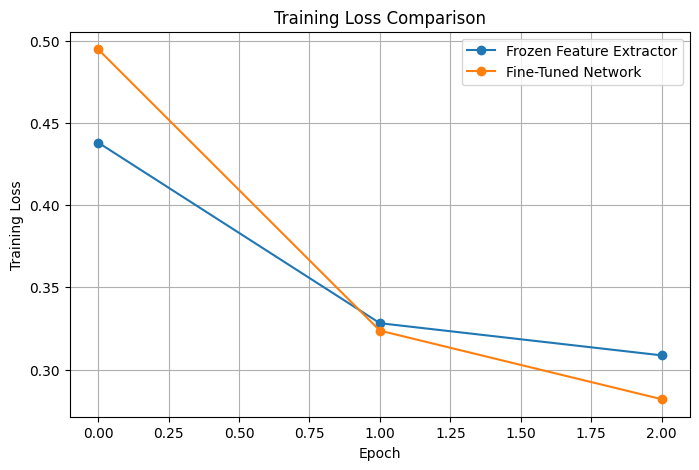

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    frozen_history.history["loss"],
    marker="o",
    label="Frozen Feature Extractor"
)

plt.plot(
    fine_tuned_history.history["loss"],
    marker="o",
    label="Fine-Tuned Network"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")

plt.legend()
plt.grid()

plt.show()

In [12]:
results = pd.DataFrame({
    "Method": [
        "Frozen Feature Extractor",
        "Fine-Tuned Network"
    ],

    "Trainable Parameters": [
        int(frozen_params),
        int(fine_tuned_params)
    ],

    "Training Time (seconds)": [
        round(frozen_time, 2),
        round(fine_tuned_time, 2)
    ],

    "Accuracy": [
        round(frozen_accuracy, 4),
        round(fine_tuned_accuracy, 4)
    ]
})

results

,Method,Trainable Parameters,Training Time (seconds),Accuracy
0,Frozen Feature Extractor,1281,24.48,0.8495
1,Fine-Tuned Network,1196161,23.85,0.8585


The frozen feature extractor had only 1,281 trainable parameters, while the fine-tuned model had 1,196,161. The frozen model reached a test accuracy of 84.95%, while the fine-tuned model reached 85.85%. The fine-tuned model also ended with a lower training loss. In this run, the training times were very similar, with the frozen model taking 24.48 seconds and the fine-tuned model taking 23.85 seconds. Fine-tuning can improve performance because some of the pretrained layers are allowed to adjust to the new dataset. Freezing the base model requires fewer parameters to be updated, which usually makes training simpler. Overall, fine-tuning gave slightly better accuracy in this experiment.